# Kmeans clustering for functional subpopulations


Just testing out a simple k-means clustering on the neuron mean rates to see if it can find meaningful subpopulations

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
from bootstrap_method import *



In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/scratch/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']


In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

## Let's load and play around w the data

In [5]:
# neural data
importlib.reload(ld)
_, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num)


In [6]:
rates_data.shape

(2055, 200, 1000)

In [28]:
# get matrix of just mean firing rate for each neuron for each trial type (time x neurons x 4 trial types)

stim1_on = int(times_ms['stim1_on'])

t = int(rates_data.shape[0] - stim1_on)
rates_mean = np.zeros((t, rates_data.shape[1], 4))
trialtype_idxs = np.zeros((t*4))
trial_types, trial_idxs = np.unique(trial_labels, axis=0, return_inverse=True)
for i, trial_type in enumerate(trial_types):
    trials_idx = (trial_idxs == i)
    trialtype_idxs[i*t:(i+1)*t] = i
    # get mean rate
    rates_mean[:,:, i] = np.mean(rates_data[stim1_on:, :, trials_idx], axis=2)

print(rates_mean.shape)
print(trialtype_idxs.shape)


(1900, 200, 4)
(7600,)


In [30]:
# concatenate 4 trial types one after another in time

rates_mean = rates_mean.transpose(2,0,1).reshape(-1, rates_mean.shape[1])
print(rates_mean.shape, trialtype_idxs.shape)

(7600, 200) (7600,)


In [33]:
N = rates_mean.shape[1]

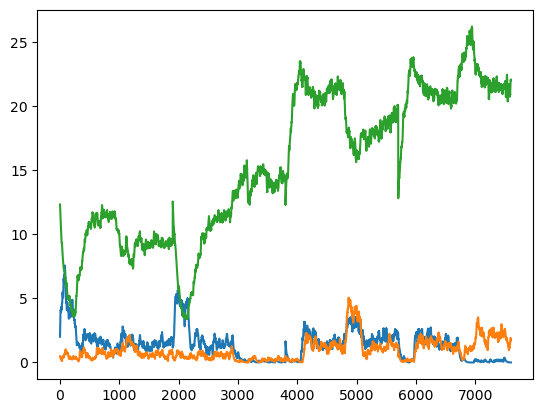

In [14]:
# plot 3 example neurons with the trials concatenated
plt.plot(rates_mean[:,0])
plt.plot(rates_mean[:,1])
plt.plot(rates_mean[:,2])

In [16]:
X_pca.shape

(7600, 200)

### some PCA plots

#### PCA on time

In [45]:
_, colors = sn.get_trialtype_colors()
trialtype_colors = [colors[int(trialtype_idxs[i])] for i in range(len(trialtype_idxs))]

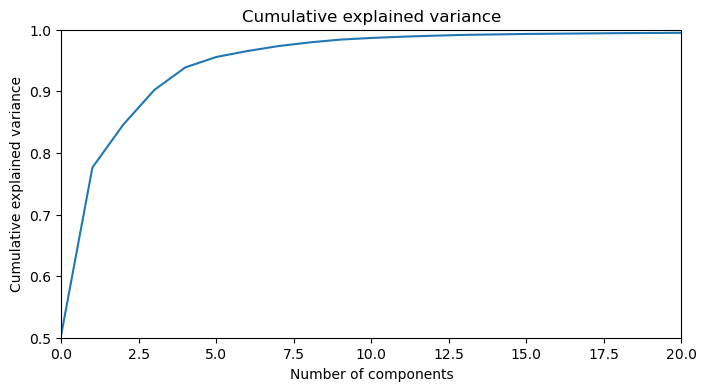

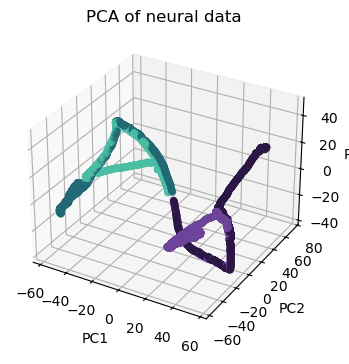

In [47]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# run PCA on the data
pca = PCA()
pca.fit(rates_mean) # time x neurons
X_pca = pca.transform(rates_mean)
varexp = pca.explained_variance_ratio_
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(varexp))
plt.title('Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.ylim(.5, 1)
plt.xlim(0, 20)

#3d plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=trialtype_colors)
ax.set_title('PCA of neural data')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

#### PCA on neurons

In [35]:
# make an array for indices of exc/inh neurons

exc_ind, inh_ind = ld.get_celltype_label(model_name)
exc = np.zeros(N)
exc[exc_ind] = 1


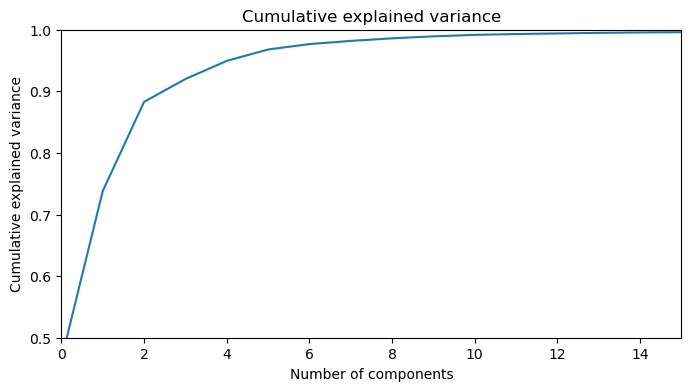

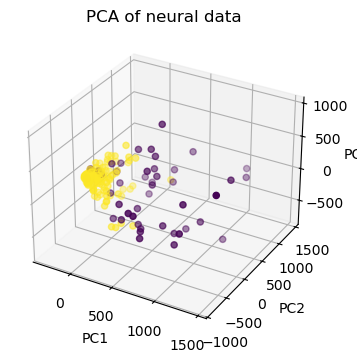

In [39]:
# run pca on the neurons instead of time

pca = PCA()
pca.fit(rates_mean.T) # neurons x time
X_pca = pca.transform(rates_mean.T)
varexp = pca.explained_variance_ratio_
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(varexp))
plt.title('Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.ylim(.5, 1)
plt.xlim(0, 15)
plt.show()

# 3d plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=exc)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA of neural data')
plt.show()

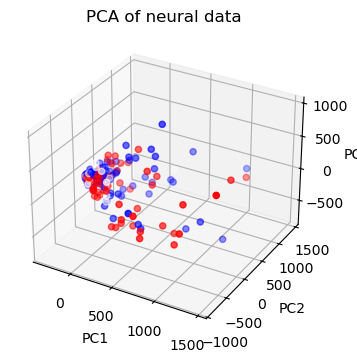

In [50]:
# color neurons by tuning

tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
tuning[np.isnan(tuning)] = 0

pca = PCA()
pca.fit(rates_mean.T) # neurons x time
X_pca = pca.transform(rates_mean.T)
varexp = pca.explained_variance_ratio_

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=tuning, cmap='bwr')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA of neural data')
plt.show()

### now cluster

(200,)


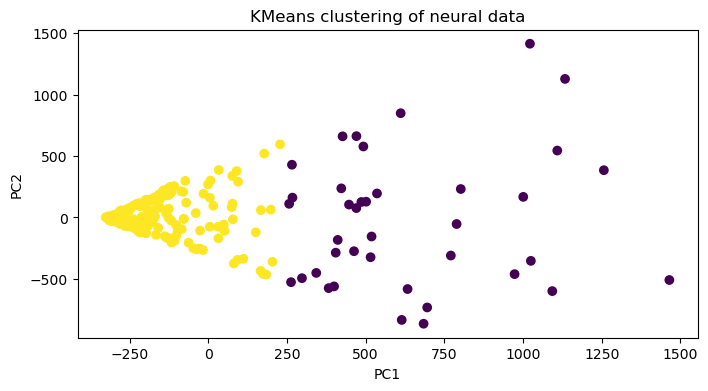

In [51]:
# kmeans clustering on the data

kmeans = KMeans(n_clusters=2, random_state=0).fit(rates_mean.T)
labels = kmeans.labels_
print(labels.shape)

# plot the clusters
plt.figure(figsize=(8, 4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title('KMeans clustering of neural data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

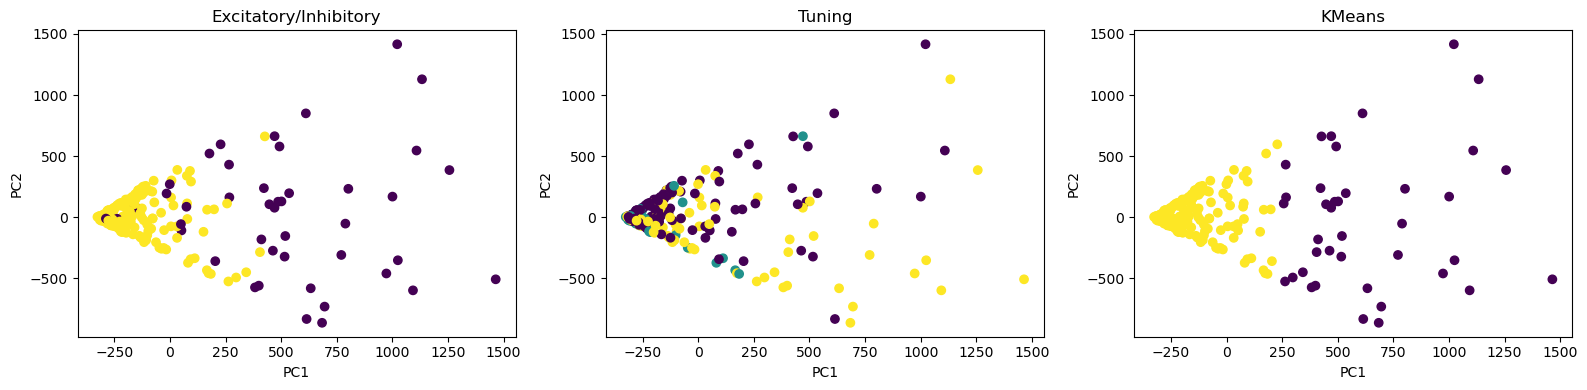

In [53]:
fig, axs = plt.subplots(1,3, figsize=(16, 4))

colors = [exc, tuning, labels]
titles = ['Excitatory/Inhibitory', 'Tuning', 'KMeans']

for i, color in enumerate(colors):
    ax = axs[i]
    ax.scatter(X_pca[:,0], X_pca[:,1], c=color, cmap='viridis')
    ax.set_title(titles[i])
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

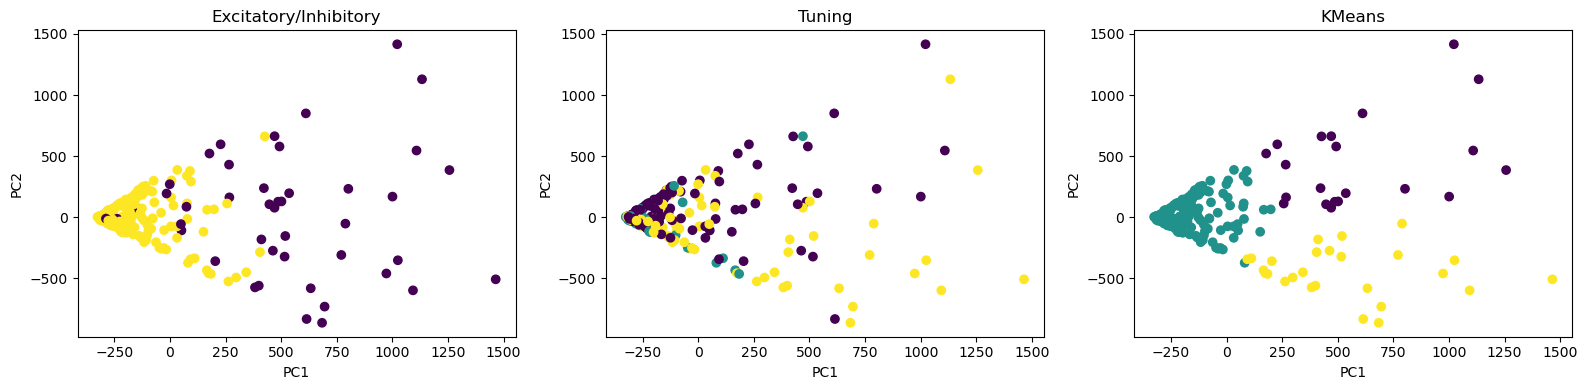

In [54]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(rates_mean.T)
labels = kmeans.labels_


fig, axs = plt.subplots(1,3, figsize=(16, 4))

colors = [exc, tuning, labels]
titles = ['Excitatory/Inhibitory', 'Tuning', 'KMeans']

for i, color in enumerate(colors):
    ax = axs[i]
    ax.scatter(X_pca[:,0], X_pca[:,1], c=color, cmap='viridis')
    ax.set_title(titles[i])
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

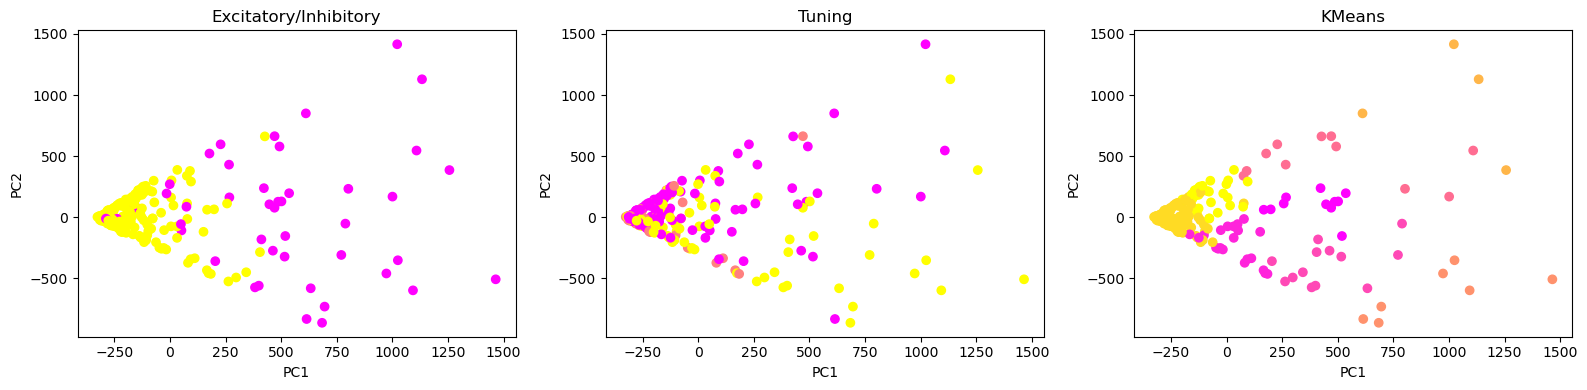

In [56]:
kmeans = KMeans(n_clusters=8, random_state=0).fit(rates_mean.T)
labels = kmeans.labels_


fig, axs = plt.subplots(1,3, figsize=(16, 4))

colors = [exc, tuning, labels]
titles = ['Excitatory/Inhibitory', 'Tuning', 'KMeans']

for i, color in enumerate(colors):
    ax = axs[i]
    ax.scatter(X_pca[:,0], X_pca[:,1], c=color, cmap='spring')
    ax.set_title(titles[i])
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [59]:
rates_mean.shape

(7600, 200)

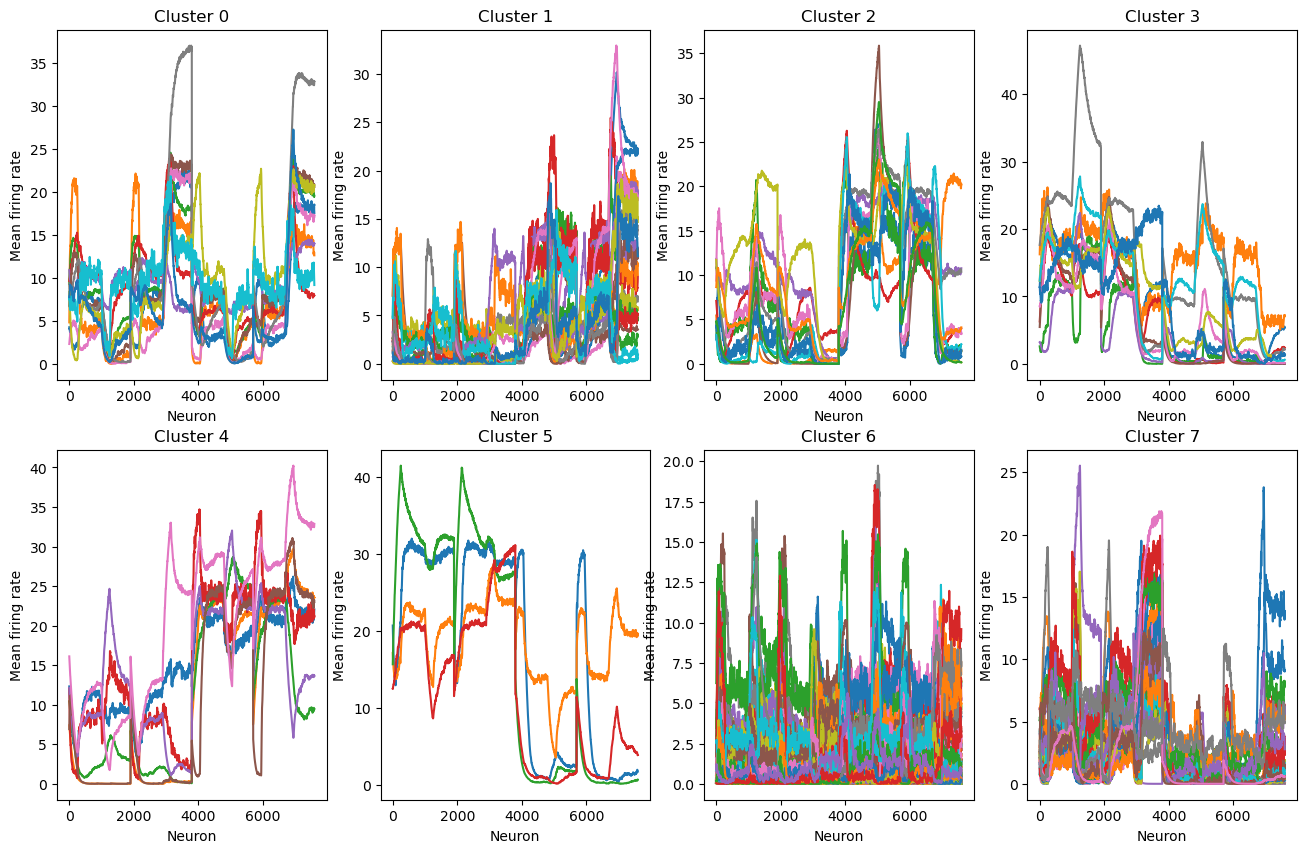

In [61]:
# plot average firing rate for each neuron in each cluster

cluster_means = np.zeros((8, N))
fig, axs = plt.subplots(2,4, figsize=(16, 10))
for i in range(8):
    ax = axs[i//4, i%4]
    ax.plot(rates_mean[:, labels == i])
    ax.set_title(f'Cluster {i}')
    ax.set_xlabel('Neuron')
    ax.set_ylabel('Mean firing rate')


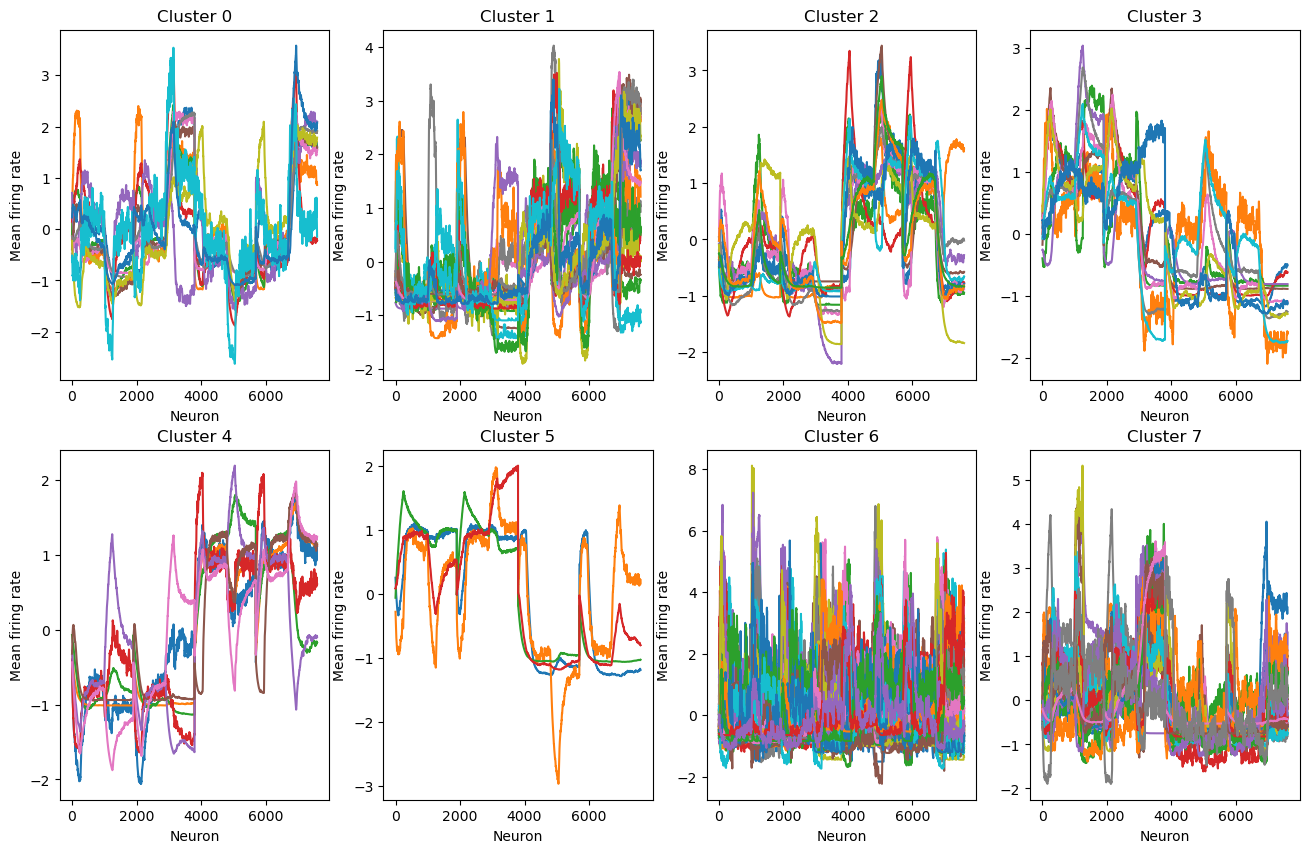

In [62]:
# plot average firing rate for each neuron in each cluster

cluster_means = np.zeros((8, N))
fig, axs = plt.subplots(2,4, figsize=(16, 10))
for i in range(8):
    ax = axs[i//4, i%4]
    ax.plot(scipy.stats.zscore(rates_mean[:, labels == i], axis=0))
    ax.set_title(f'Cluster {i}')
    ax.set_xlabel('Neuron')
    ax.set_ylabel('Mean firing rate')


In [79]:
rates_mean.shape

(7600, 200)

In [81]:
rates_mean_zscore.shape

(7600, 28)

In [82]:
np.mean(rates_mean_zscore, axis=1).shape

(7600,)

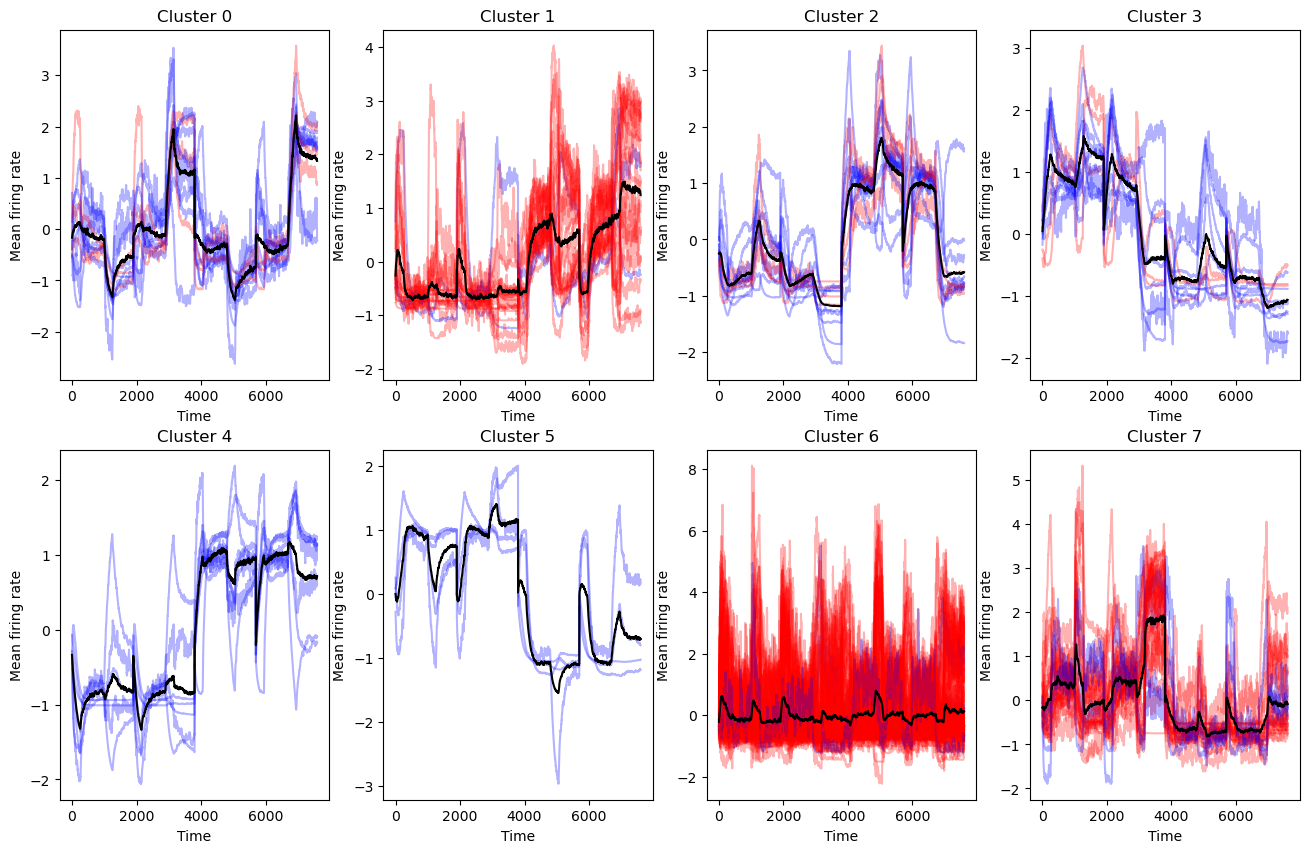

In [87]:
# plot average firing rate for each neuron in each cluster

exc_colors = ['r' if i in exc_ind else 'b' for i in range(N)]

cluster_means = np.zeros((8, N))
fig, axs = plt.subplots(2,4, figsize=(16, 10))
for i in range(8):
    ax = axs[i//4, i%4]
    idxs = np.where(labels == i)[0]
    rates_mean_zscore = scipy.stats.zscore(rates_mean[:, idxs], axis=0)
    # cluster_mean = np.mean(rates_mean[:, idxs], axis=1)
    exc_colors = ['red' if j==1 else 'blue' for j in exc[idxs]]
    for j in range(len(idxs)):
        ax.plot(rates_mean_zscore[:, j], color=exc_colors[j], alpha=0.3)
    ax.plot(np.mean(rates_mean_zscore, axis=1), color='k', alpha=1)
    ax.set_title(f'Cluster {i}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Mean firing rate')
